# Photovoltaic Module Temperature Forecasting

## 03 - Model Evaluation

This notebook trains and evaluates machine learning regression models to predict photovoltaic module temperature using Global Irradiance and Ambient Temperature as predictor variables.

The models evaluated are Multiple Linear Regression, Decision Tree, Random Forest, and Support Vector Regression (SVR).

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

## 2. Data Loading

In [2]:
df = pd.read_csv(
    "../data/processed/pv_module_temperature_clean.csv"
)

df["UpdatedTime"] = pd.to_datetime(df["UpdatedTime"])

df.shape

(42532, 4)

## 3. Feature and Target Definition

In [3]:
X = df[
    [
        "IrradianceGlobal",
        "TemperatureAmbient"
    ]
]

y = df["TemperatureModules"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (42532, 2)
Target shape: (42532,)


## 4. Temporal Train-Test Split

In [4]:
split_index = int(len(df) * 0.70)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 29772
Test samples: 12760


In [5]:
print(
    "Chronological order:",
    df["UpdatedTime"].is_monotonic_increasing
)

Chronological order: True


## 5. Model Evaluation

In [6]:
def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)

    return {
        "R²": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse)
    }

### 5.1 Multiple Linear Regression

In [7]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

y_train_pred_lr = linear_model.predict(X_train)
y_test_pred_lr = linear_model.predict(X_test)

lr_train_metrics = evaluate_regression(
    y_train,
    y_train_pred_lr
)

lr_test_metrics = evaluate_regression(
    y_test,
    y_test_pred_lr
)

lr_results = pd.DataFrame(
    {
        "Train": lr_train_metrics,
        "Test": lr_test_metrics
    }
).T

lr_results.round(4)

,R²,MAE,MSE,RMSE
Train,0.8904,2.1900,8.9780,2.9963
Test,0.8516,2.3972,10.4215,3.2282


The Multiple Linear Regression results exactly reproduce the performance reported in the original study. The model achieved an R² of 0.8904 on the training set and 0.8516 on the test set, with a test RMSE of 3.2282 °C. This confirms the consistency of the reconstructed preprocessing and temporal train-test split.

### 5.2 Decision Tree

In [8]:
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

y_train_pred_dt = decision_tree_model.predict(X_train)
y_test_pred_dt = decision_tree_model.predict(X_test)

dt_train_metrics = evaluate_regression(
    y_train,
    y_train_pred_dt
)

dt_test_metrics = evaluate_regression(
    y_test,
    y_test_pred_dt
)

dt_results = pd.DataFrame(
    {
        "Train": dt_train_metrics,
        "Test": dt_test_metrics
    }
).T

dt_results.round(4)

,R²,MAE,MSE,RMSE
Train,0.9990,0.0387,0.0809,0.2845
Test,0.8054,2.6207,13.6667,3.6969


#### 5.2.1 Decision Tree Hyperparameter Tuning

In [9]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid_dt = {
    "max_depth": [4, 6, 8, 10, 12],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10, 20]
}

grid_search_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    scoring="r2",
    cv=tscv,
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)

print("Best parameters:")
print(grid_search_dt.best_params_)

print("\nBest validation R²:")
print(round(grid_search_dt.best_score_, 4))

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 2}

Best validation R²:
0.8837


In [10]:
best_dt_model = grid_search_dt.best_estimator_

y_train_pred_dt_tuned = best_dt_model.predict(X_train)
y_test_pred_dt_tuned = best_dt_model.predict(X_test)

dt_tuned_train_metrics = evaluate_regression(
    y_train,
    y_train_pred_dt_tuned
)

dt_tuned_test_metrics = evaluate_regression(
    y_test,
    y_test_pred_dt_tuned
)

dt_tuned_results = pd.DataFrame(
    {
        "Train": dt_tuned_train_metrics,
        "Test": dt_tuned_test_metrics
    }
).T

dt_tuned_results.round(4)

,R²,MAE,MSE,RMSE
Train,0.9360,1.5714,5.2437,2.2899
Test,0.8918,1.9470,7.6011,2.7570


In [11]:
dt_comparison = pd.DataFrame({
    "Default DT": dt_test_metrics,
    "Tuned DT": dt_tuned_test_metrics
}).T

dt_comparison.round(4)

,R²,MAE,MSE,RMSE
Default DT,0.8054,2.6207,13.6667,3.6969
Tuned DT,0.8918,1.9470,7.6011,2.7570


The default Decision Tree showed strong overfitting, achieving an R² of 0.9990 on the training set but only 0.8054 on the test set.

To improve generalization, hyperparameters were optimized using GridSearchCV with TimeSeriesSplit, preserving the temporal structure of the training data. The best configuration used a maximum depth of 10, a minimum of 20 samples per leaf, and 2 samples required to split an internal node.

After tuning, the test R² increased to 0.8918 while the RMSE decreased from 3.6969 °C to 2.7570 °C. The tuned model also slightly outperformed the Decision Tree results reported in the original study, which achieved a test R² of 0.8875.

### 5.3 Random Forest

In [12]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

y_train_pred_rf = random_forest_model.predict(X_train)
y_test_pred_rf = random_forest_model.predict(X_test)

rf_train_metrics = evaluate_regression(
    y_train,
    y_train_pred_rf
)

rf_test_metrics = evaluate_regression(
    y_test,
    y_test_pred_rf
)

rf_results = pd.DataFrame(
    {
        "Train": rf_train_metrics,
        "Test": rf_test_metrics
    }
).T

rf_results.round(4)

,R²,MAE,MSE,RMSE
Train,0.9881,0.6638,0.9721,0.9859
Test,0.8715,2.1367,9.0267,3.0045


#### 5.3.1 Random Forest Hyperparameter Tuning

In [13]:
param_grid_rf = {
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [10, 20, 30],
    "max_features": [1.0, "sqrt"]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid_rf,
    scoring="r2",
    cv=tscv,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best parameters:")
print(grid_search_rf.best_params_)

print("\nBest validation R²:")
print(round(grid_search_rf.best_score_, 4))

Best parameters:
{'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'min_samples_split': 2}

Best validation R²:
0.8969


In [14]:
best_rf_model = grid_search_rf.best_estimator_

y_train_pred_rf_tuned = best_rf_model.predict(X_train)
y_test_pred_rf_tuned = best_rf_model.predict(X_test)

rf_tuned_train_metrics = evaluate_regression(
    y_train,
    y_train_pred_rf_tuned
)

rf_tuned_test_metrics = evaluate_regression(
    y_test,
    y_test_pred_rf_tuned
)

rf_tuned_results = pd.DataFrame(
    {
        "Train": rf_tuned_train_metrics,
        "Test": rf_tuned_test_metrics
    }
).T

rf_tuned_results.round(4)

,R²,MAE,MSE,RMSE
Train,0.9326,1.6065,5.5168,2.3488
Test,0.8984,1.8751,7.1361,2.6713


In [15]:
rf_comparison = pd.DataFrame({
    "Default RF": rf_test_metrics,
    "Tuned RF": rf_tuned_test_metrics
}).T

rf_comparison.round(4)

,R²,MAE,MSE,RMSE
Default RF,0.8715,2.1367,9.0267,3.0045
Tuned RF,0.8984,1.8751,7.1361,2.6713


The default Random Forest showed signs of overfitting, achieving an R² of 0.9881 on the training set but only 0.8715 on the test set.

Hyperparameter tuning with GridSearchCV and TimeSeriesSplit substantially improved generalization. The optimized model used a maximum depth of 8, 30 minimum samples per leaf, and the square-root feature selection strategy.

The tuned Random Forest achieved an R² of 0.8984 and an RMSE of 2.6713 °C on the test set. Its validation R² of 0.8969 was also very close to the test performance, indicating consistent generalization. The result is slightly better than the Random Forest performance reported in the original study.

### 5.4 Support Vector Regression

In [16]:
svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

svr_model.fit(X_train, y_train)

y_train_pred_svr = svr_model.predict(X_train)
y_test_pred_svr = svr_model.predict(X_test)

svr_train_metrics = evaluate_regression(
    y_train,
    y_train_pred_svr
)

svr_test_metrics = evaluate_regression(
    y_test,
    y_test_pred_svr
)

svr_results = pd.DataFrame(
    {
        "Train": svr_train_metrics,
        "Test": svr_test_metrics
    }
).T

svr_results.round(4)

,R²,MAE,MSE,RMSE
Train,0.9265,1.6379,6.0169,2.4529
Test,0.9005,1.7882,6.9873,2.6434


The default SVR already demonstrated strong generalization, achieving an R² of 0.9265 on the training set and 0.9005 on the test set.

The model slightly outperformed the SVR result reported in the original study, which achieved a test R² of 0.9004. Feature scaling was performed within a Pipeline to ensure that preprocessing is learned only from the appropriate training data.

#### 5.4.1 Support Vector Regression Hyperparameter Tuning

In [17]:
param_grid_svr = {
    "svr__C": [1, 10],
    "svr__epsilon": [0.05, 0.1, 0.2],
    "svr__gamma": ["scale"]
}

grid_search_svr = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ]),
    param_grid=param_grid_svr,
    scoring="r2",
    cv=tscv,
    n_jobs=-1
)

grid_search_svr.fit(X_train, y_train)

print("Best parameters:")
print(grid_search_svr.best_params_)

print("\nBest validation R²:")
print(round(grid_search_svr.best_score_, 4))

Best parameters:
{'svr__C': 1, 'svr__epsilon': 0.05, 'svr__gamma': 'scale'}

Best validation R²:
0.9036


In [18]:
best_svr_model = grid_search_svr.best_estimator_

y_train_pred_svr_tuned = best_svr_model.predict(X_train)
y_test_pred_svr_tuned = best_svr_model.predict(X_test)

svr_tuned_train_metrics = evaluate_regression(
    y_train,
    y_train_pred_svr_tuned
)

svr_tuned_test_metrics = evaluate_regression(
    y_test,
    y_test_pred_svr_tuned
)

svr_tuned_results = pd.DataFrame(
    {
        "Train": svr_tuned_train_metrics,
        "Test": svr_tuned_test_metrics
    }
).T

svr_tuned_results.round(4)

,R²,MAE,MSE,RMSE
Train,0.9266,1.6378,6.0134,2.4522
Test,0.9006,1.7881,6.9849,2.6429


In [19]:

svr_comparison = pd.DataFrame({
    "Default SVR": svr_test_metrics,
    "Tuned SVR": svr_tuned_test_metrics
}).T

svr_comparison.round(4)

,R²,MAE,MSE,RMSE
Default SVR,0.9005,1.7882,6.9873,2.6434
Tuned SVR,0.9006,1.7881,6.9849,2.6429


The default SVR already showed strong predictive performance and good generalization.

Hyperparameter tuning with GridSearchCV and TimeSeriesSplit selected C = 1, epsilon = 0.05, and gamma = "scale". The tuned model achieved a validation R² of 0.9036 and a test R² of 0.9006.

The improvement over the default SVR was marginal, indicating that the default configuration was already well suited to this dataset. Nevertheless, the tuned model was retained because its hyperparameters were selected using time-aware validation without using the test set.

## 6. Final Model Comparison

In [20]:
final_results = pd.DataFrame({
    "Multiple Linear Regression": lr_test_metrics,
    "Decision Tree": dt_tuned_test_metrics,
    "Random Forest": rf_tuned_test_metrics,
    "SVR": svr_tuned_test_metrics
}).T

final_results = final_results.sort_values(
    by="R²",
    ascending=False
)

final_results.round(4)

,R²,MAE,MSE,RMSE
SVR,0.9006,1.7881,6.9849,2.6429
Random Forest,0.8984,1.8751,7.1361,2.6713
Decision Tree,0.8918,1.9470,7.6011,2.7570
Multiple Linear Regression,0.8516,2.3972,10.4215,3.2282


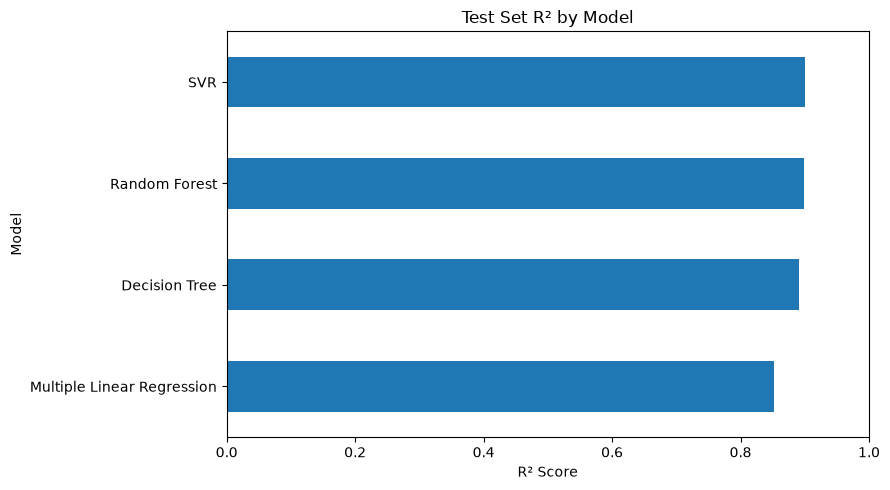

In [21]:
plt.figure(figsize=(9, 5))

final_results["R²"].sort_values().plot(
    kind="barh"
)

plt.xlabel("R² Score")
plt.ylabel("Model")
plt.title("Test Set R² by Model")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

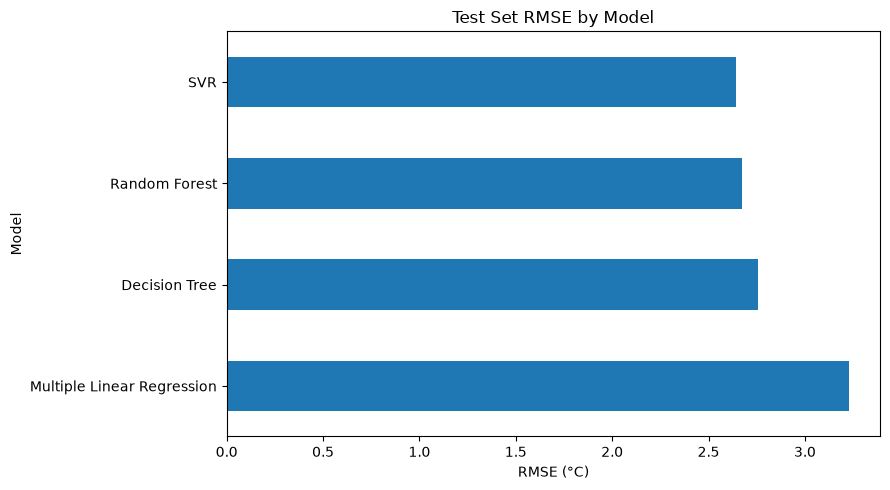

In [22]:
plt.figure(figsize=(9, 5))

final_results["RMSE"].sort_values(
    ascending=False
).plot(
    kind="barh"
)

plt.xlabel("RMSE (°C)")
plt.ylabel("Model")
plt.title("Test Set RMSE by Model")

plt.tight_layout()
plt.show()

## 7. Original Study vs. Revised Implementation

In [23]:
original_results = pd.DataFrame({
    "Multiple Linear Regression": {
        "R²": 0.8516,
        "MAE": 2.3972,
        "MSE": 10.4215,
        "RMSE": 3.2282
    },
    "Decision Tree": {
        "R²": 0.8875,
        "MAE": 1.9998,
        "MSE": 7.9039,
        "RMSE": 2.8114
    },
    "Random Forest": {
        "R²": 0.8978,
        "MAE": 1.8805,
        "MSE": 7.1796,
        "RMSE": 2.6795
    },
    "SVR": {
        "R²": 0.9004,
        "MAE": 1.7945,
        "MSE": 6.9958,
        "RMSE": 2.6450
    }
}).T

comparison_study = pd.DataFrame({
    "Original R²": original_results["R²"],
    "Revised R²": final_results["R²"],
    "Δ R²": final_results["R²"] - original_results["R²"],
    "Original RMSE": original_results["RMSE"],
    "Revised RMSE": final_results["RMSE"],
    "Δ RMSE": final_results["RMSE"] - original_results["RMSE"]
})

comparison_study.round(4)

,Original R²,Revised R²,Δ R²,Original RMSE,Revised RMSE,Δ RMSE
Decision Tree,0.8875,0.8918,0.0043,2.8114,2.7570,-0.0544
Multiple Linear Regression,0.8516,0.8516,0.0000,3.2282,3.2282,0.0000
Random Forest,0.8978,0.8984,0.0006,2.6795,2.6713,-0.0082
SVR,0.9004,0.9006,0.0002,2.6450,2.6429,-0.0021


The revised implementation preserved the main conclusion of the original study: SVR and Random Forest provided the strongest predictive performance.

Multiple Linear Regression reproduced the original test results exactly. The revised Decision Tree showed the largest improvement, increasing test R² from 0.8875 to 0.8918 while reducing RMSE from 2.8114 °C to 2.7570 °C.

Random Forest and SVR also achieved small improvements. These gains were obtained through time-aware hyperparameter tuning using only the training data, while the final test set remained isolated for model evaluation.

## 8. Prediction and Residual Analysis

### 8.1 Actual vs. Predicted

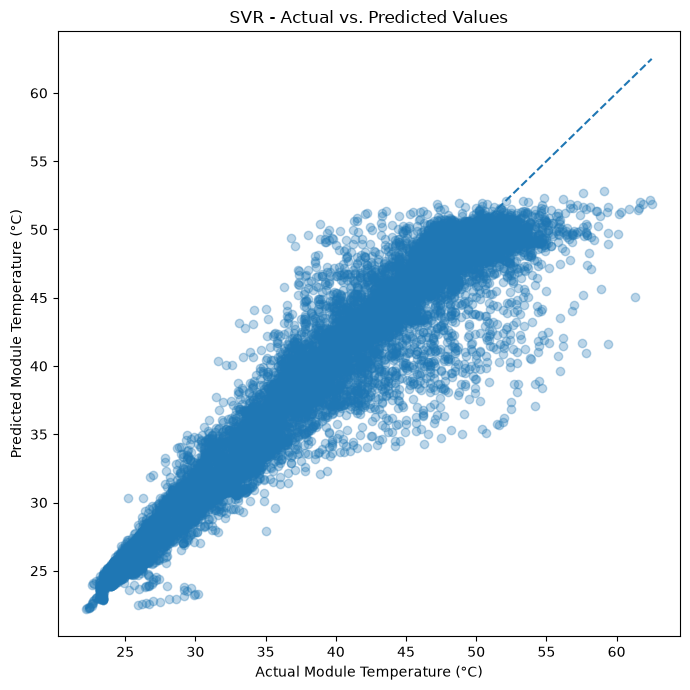

In [24]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    y_test_pred_svr_tuned,
    alpha=0.3
)

min_value = min(y_test.min(), y_test_pred_svr_tuned.min())
max_value = max(y_test.max(), y_test_pred_svr_tuned.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Module Temperature (°C)")
plt.ylabel("Predicted Module Temperature (°C)")
plt.title("SVR - Actual vs. Predicted Values")

plt.tight_layout()
plt.show()

### 8.2 Residual Analysis

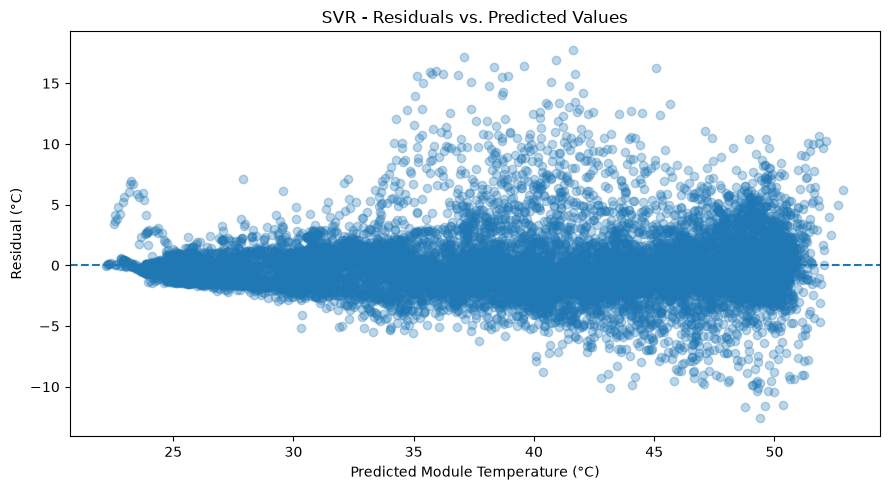

In [25]:
svr_residuals = y_test - y_test_pred_svr_tuned

plt.figure(figsize=(9, 5))

plt.scatter(
    y_test_pred_svr_tuned,
    svr_residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Module Temperature (°C)")
plt.ylabel("Residual (°C)")
plt.title("SVR - Residuals vs. Predicted Values")

plt.tight_layout()
plt.show()

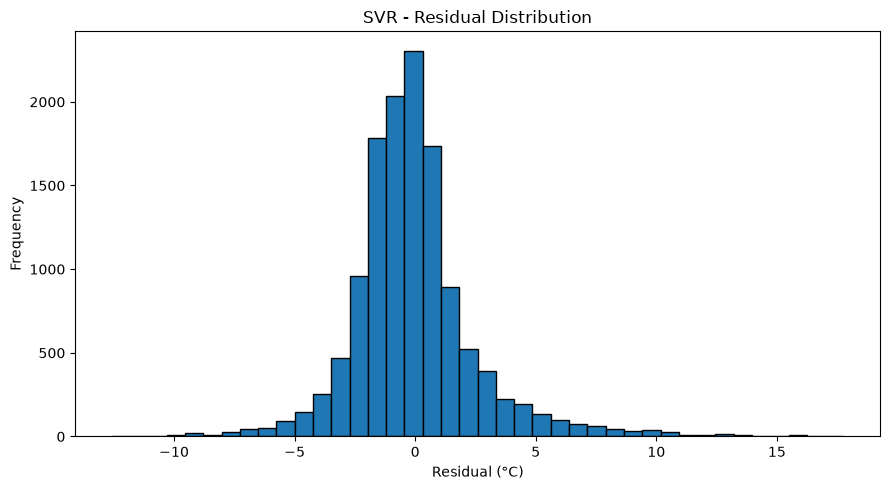

In [26]:
plt.figure(figsize=(9, 5))

plt.hist(
    svr_residuals,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Residual (°C)")
plt.ylabel("Frequency")
plt.title("SVR - Residual Distribution")

plt.tight_layout()
plt.show()

### Residual Analysis Interpretation

The residuals are predominantly concentrated around zero, indicating that the SVR model does not exhibit a strong overall systematic bias.

However, the dispersion of the residuals increases as predicted module temperature rises. This suggests that prediction uncertainty is greater for higher operating temperatures, with some observations presenting relatively large positive and negative errors.

The residual distribution is strongly concentrated near zero but presents tails on both sides, indicating the presence of a limited number of larger prediction errors. Since SVR does not assume normally distributed residuals, this behavior does not invalidate the model, but it highlights temperature ranges where prediction performance may be less consistent.

### 8.3 Residual Summary

In [27]:
residual_summary = pd.Series({
    "Mean Residual (°C)": svr_residuals.mean(),
    "Median Residual (°C)": svr_residuals.median(),
    "Residual Std. Dev. (°C)": svr_residuals.std(),
    "Minimum Residual (°C)": svr_residuals.min(),
    "Maximum Residual (°C)": svr_residuals.max(),
    "Errors within ±2 °C (%)": (svr_residuals.abs() <= 2).mean() * 100,
    "Errors within ±3 °C (%)": (svr_residuals.abs() <= 3).mean() * 100,
    "Errors within ±5 °C (%)": (svr_residuals.abs() <= 5).mean() * 100
})

residual_summary.round(2)

Mean Residual (°C)         -0.05
Median Residual (°C)       -0.28
Residual Std. Dev. (°C)     2.64
Minimum Residual (°C)     -12.58
Maximum Residual (°C)      17.76
Errors within ±2 °C (%)    70.31
Errors within ±3 °C (%)    83.79
Errors within ±5 °C (%)    93.60
dtype: float64

### Residual Summary Interpretation

The tuned SVR presented a mean residual of -0.05 °C and a median residual of -0.28 °C, indicating negligible overall prediction bias.

Approximately 70.31% of the test predictions were within ±2 °C of the observed module temperature, while 83.79% were within ±3 °C and 93.60% were within ±5 °C.

Although most predictions showed relatively small errors, a limited number of observations presented larger deviations, ranging from -12.58 °C to 17.76 °C. These extreme residuals are consistent with the increased error dispersion observed at higher module temperatures.

## 9. Key Findings

- The chronological 70/30 train-test split preserved the temporal structure of the dataset, resulting in 29,772 training observations and 12,760 test observations.

- Multiple Linear Regression exactly reproduced the test performance reported in the original study, achieving an R² of 0.8516 and an RMSE of 3.2282 °C.

- The default Decision Tree and Random Forest models showed clear signs of overfitting. Time-aware hyperparameter tuning substantially improved their generalization performance.

- The tuned Decision Tree achieved a test R² of 0.8918 and an RMSE of 2.7570 °C.

- The tuned Random Forest achieved a test R² of 0.8984 and an RMSE of 2.6713 °C.

- SVR achieved the best overall performance, with a test R² of 0.9006, MAE of 1.7881 °C, and RMSE of 2.6429 °C.

- The revised implementation preserved the ranking observed in the original study: SVR, Random Forest, Decision Tree, and Multiple Linear Regression.

- The SVR residual mean was close to zero (-0.05 °C), indicating negligible systematic bias.

- Approximately 70.31% of SVR predictions were within ±2 °C of the observed temperature, 83.79% within ±3 °C, and 93.60% within ±5 °C.

- Residual dispersion increased for higher predicted module temperatures, suggesting that prediction uncertainty is greater under higher-temperature operating conditions.

## 10. Conclusion

The revised analysis confirms the main conclusion of the original study: nonlinear machine learning models outperform Multiple Linear Regression for predicting photovoltaic module temperature from global irradiance and ambient temperature.

Among the evaluated approaches, Support Vector Regression provided the strongest predictive performance and the most consistent generalization, achieving an R² of 0.9006 and an RMSE of 2.6429 °C on the temporally isolated test set.

The revised implementation also improved methodological robustness by introducing time-aware hyperparameter tuning, feature scaling within a Pipeline, and detailed residual analysis.

Overall, the results demonstrate that global irradiance and ambient temperature provide sufficient predictive information to estimate photovoltaic module temperature with good accuracy, although prediction uncertainty increases under higher-temperature operating conditions.